# Retriever

In this notebook we will implement:
- A retriever based on similarity search using the embeddings of the documents.
- Different re-rankers using the following classifiers:
    - A transformer classifier using a NLI model trained in the `2_TRF_Classifier.ipynb` notebook.
    - An LLM scorer that takes as input the image and the text and outputs a score.
    - A Random Forest classifier trained in the `1_ML_Classifier.ipynb` notebook that uses different features to score the documents.
    - A hard voting ensemble of the previous models.


In [1]:
import pandas as pd
import numpy as np
import torch
from tqdm import tqdm
import re
tqdm.pandas()

from sentence_transformers import SentenceTransformer, util
from transformers import AutoTokenizer
import json

def recall_at_k(preds, targets, k):
    """
    Compute recall at k: the number of correct items in the top-k recommendations divided by the number of correct items
    """
    return len(set(preds[:k]).intersection(set(targets))) / len(targets)

def map_at_k(preds, targets, k):
    """
    Compute mean average precision at k: the average of precision at i from 1 to k. 
    Precision at i is the number of correct items in the top-i recommendations divided by i
    """
    score = 0
    num_hits = 0
    for i, p in enumerate(preds[:k]):
        if p in targets:
            num_hits += 1
            score += num_hits / (i + 1)
    return score / k

def mrr(preds, targets):
    """
    Compute mean reciprocal rank: the reciprocal of the rank of the first correct item in the recommendations.
    The reciprocal of the rank is 1 for the first correct item, 1/2 for the second, 1/3 for the third, and so on.
    """
    for i, p in enumerate(preds):
        if p in targets:
            return 1 / (i + 1)
    return 0

def compute_metrics(df, ls_k):
    metrics = {"recall": {}, "map": {}, "mrr": None}
    for k in ls_k:
        metrics["recall"][k] = df.apply(lambda x: recall_at_k(x["pred_urls"], x["label"], k), axis=1).mean()
        metrics[f"map"][k] = df.apply(lambda x: map_at_k(x["pred_urls"], x["label"], k), axis=1).mean()
    metrics["mrr"] = df.apply(lambda x: mrr(x["pred_urls"], x["label"]), axis=1).mean()
    return pd.DataFrame(metrics).T

EMB_MODEL_NAME = "intfloat/multilingual-e5-large"
CE_MODEL_NAME = "cross-encoder/nli-deberta-v3-large"

# Load Data

In [ ]:
# Load the dataset and also the splits created in "0_Data_Splitting.ipynb"
df = pd.read_csv("nbs/other/claim_matching_dataset.csv")
df = df.drop(columns=["Unnamed: 0", "Unnamed: 0.1", "dataset"])

d_splits = json.load(open("nbs/other/splits.json"))

# Separate the claims and fact-checks by creating a unique id for each
df_claims = df[["unverified claim"]].drop_duplicates().reset_index().rename(columns={"index": "claim_id"})

df = df.merge(df_claims, on="unverified claim", how="left")

# We create the label by aggregating the urls corresponding to each fact check for that claim
df_claims = df[["claim_id", "unverified claim", "url", "similarity"]].copy()
df_claims = df_claims.groupby(["claim_id", "unverified claim", "similarity"]).agg({"url": list}).reset_index()
df_claims = df_claims[df_claims["similarity"] == 1].drop(columns=["similarity"])
df_claims.rename(columns={"url": "label"}, inplace=True)


df_claims.head()

In [ ]:
# Create a separate dataframe for the unique fact-checks to create the search index
df_fc = df.drop(columns=["unverified claim", "claim_id", "similarity"]).copy()
df_fc = df_fc.drop_duplicates(subset=["url"]).reset_index().rename(columns={"index": "fc_id"})

df_fc.head()

,fc_id,reviewed claim,url,title,text,summary,meta_description,kb_keywords,meta_keywords,cr_country,meta_lang,cr_image,meta_image,movies,domain,cm_authors,cr_author_name,cr_author_url,cr_item_reviewed_text
0,0,Dióxido de cloro ayuda a sanar esclerosis múlt...,https://factual.afp.com/doc.afp.com.32GA6AY,El dióxido de cloro no “ayuda a sanar” la escl...,El dióxido de cloro no “ayuda a sanar” la escl...,El dióxido de cloro no tiene propiedades aprob...,El dióxido de cloro no tiene propiedades aprob...,"[('dióxido de cloro', 0.553), ('osteoporosis e...",[''],Mexico,es,https://factual.afp.com/sites/default/files/st...,https://factual.afp.com/sites/default/files/st...,[],factual.afp.com,[],AFP Factual,factual.afp.com,Dióxido de cloro ayuda a sanar esclerosis múlt...
1,1,El dióxido de cloro tiene propiedades curativas,https://www.europapress.es/verificaciones/noti...,Cuidado con los mensajes que recomiendan las i...,Archivo - Investigador probando muestras en un...,Se ha difundido un mensaje en redes sociales s...,Está circulando en redes sociales un mensaje q...,"[('dióxido de cloro', 0.6435), ('cloro en apli...",[''],Spain,es,https://img.europapress.es/fotoweb/fotonoticia...,https://img.europapress.es/fotoweb/fotonoticia...,[],www.europapress.es,"['Europa Press Verificaciones', 'Europa Press']",Europa Press,europapress.es,El dióxido de cloro tiene propiedades curativas
2,2,Centenas de pilotos de avião protestam contra ...,https://poligrafo.sapo.pt/fact-check/video-mos...,Vídeo mostra centenas de pilotos de avião a pr...,"""Última hora! Greve de mais de 400 pilotos do ...",Uma greve de mais de 400 pilotos no aeroporto ...,"Do TikTok para o Instagram e Facebook, o vídeo...","[('vídeo que está', 0.5972), ('de vídeo que', ...",[''],Portugal,pt,https://thumbs.web.sapo.io/?W=1200&H=630&delay...,https://thumbs.web.sapo.io/?W=1200&H=630&delay...,[],poligrafo.sapo.pt,"['Polígrafo', 'Gustavo Sampaio']",Polígrafo - SAPO,poligrafo.sapo.pt,Centenas de pilotos de avião protestam contra ...
3,3,Delta Pilots In Video Were Protesting COVID-19...,https://leadstories.com/hoax-alert/2022/07/fac...,Fact Check: Delta Pilots In Video Were NOT Pro...,Protesting Pay\n\nDoes this video show Delta A...,The video circulating on TikTok showing Delta ...,Does this video show Delta Air Lines pilots pr...,"[('delta pilots protesting', 0.7006), ('delta ...","['coronavirus', 'fact check', '', 'Delta pilot...",United States,en,https://leadstories.com/caption_3479196.jpg,https://leadstories.com/caption_3479196.jpg,[],leadstories.com,"['Lead Stories Staff', 'Lead Stories LLC']",Lead Stories,leadstories.com,Delta Pilots In Video Were Protesting COVID-19...
4,4,Des pilotes de Delta Airlines manifestent cont...,https://factuel.afp.com/doc.afp.com.32DY8NY,"Non, ces pilotes de Delta Airlines ne manifest...","Non, ces pilotes de Delta Airlines ne manifest...",Des vidéos sur Twitter prétendant montrer des ...,Une vidéo visionnée des milliers de fois sur T...,"[('les vaccins mais', 0.544), ('pilotes de del...",[''],France,fr,https://factuel.afp.com/sites/default/files/st...,https://factuel.afp.com/sites/default/files/st...,[],factuel.afp.com,[],AFP Factuel,factuel.afp.com,Des pilotes de Delta Airlines manifestent cont...


In [ ]:
## Create Train-Test Split
# Note: In the split creations we make sure to keep the same claims in the same split

idx_train = df.loc[d_splits["train"], "claim_id"].unique()
idx_val = df.loc[d_splits["val"], "claim_id"].unique()
idx_test = df.loc[d_splits["test"], "claim_id"].unique()

df_train = df_claims[df_claims["claim_id"].isin(idx_train)].reset_index(drop=True)
df_val = df_claims[df_claims["claim_id"].isin(idx_val)].reset_index(drop=True)
df_test = df_claims[df_claims["claim_id"].isin(idx_test)].reset_index(drop=True)

print("There are in total", len(df_claims), "claims")
print("There are in total", len(df_fc), "fact-checks")
print()
print("There are in total", len(df_train), "train claims")
print("There are in total", len(df_val), "val claims")
print("There are in total", len(df_test), "test claims")

There are in total 219 claims
There are in total 2967 fact-checks

There are in total 202 train claims
There are in total 36 val claims
There are in total 36 test claims


# Biencoder Retriever

Use the biencoder model to encode the documents and the query. Then, use the cosine similarity to retrieve the top-k documents.

`intfloat/multilingual-e5-large` is used as the biencoder model. The reason for using this model is that it is a multilingual model that can handle multiple languages.

In [113]:
df_ver_claims = df_fc.copy()
df_ver_claims["full_text"] = df_ver_claims["reviewed claim"]
df_ver_claims = df_ver_claims.drop_duplicates(subset=["url"])

# Load the model
model = SentenceTransformer(EMB_MODEL_NAME, device="cuda:1")
model.max_seq_length

emb_pool = model.encode(df_ver_claims["full_text"].values, 
                        show_progress_bar=True, 
                        convert_to_tensor=True,
                        normalize_embeddings=True)

No sentence-transformers model found with name intfloat/multilingual-e5-large. Creating a new one with mean pooling.


Batches:   0%|          | 0/93 [00:00<?, ?it/s]

In [ ]:
print(df.shape)
print(df_ver_claims.shape)

(3868, 21)
(2967, 20)


In [ ]:
emb_pool.shape

torch.Size([2967, 1024])

In [ ]:
# Compute the cosine similarity between the claims and the fact checks

def compute_batch_similarities(queries, emb_pool, model):
    query_embs = model.encode(queries, convert_to_tensor=True, normalize_embeddings=True)
    cos_scores = util.pytorch_cos_sim(query_embs, emb_pool)
    return cos_scores

cos_scores = compute_batch_similarities(df_val["unverified claim"].tolist(), emb_pool, model)

# Sort the similarities in descending order
idx_sim = torch.argsort(- cos_scores, dim=1)
sorted_sim = - torch.sort(-cos_scores, dim=1).values

idx_sim.shape, sorted_sim.shape 

torch.Size([36, 2967])

In [ ]:
df_preds = df_val.copy()
df_preds["idxs"] = idx_sim.tolist()
df_preds["sims"] = sorted_sim.tolist()
df_preds["pred_urls"] = df_preds.progress_apply(lambda x: [df_ver_claims.iloc[i]["url"] for i in x["idxs"]], axis=1)
df_preds["pred_txts"] = df_preds.progress_apply(lambda x: [df_ver_claims.iloc[i]["full_text"] for i in x["idxs"]], axis=1)
df_preds.head()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 36/36 [00:02<00:00, 15.89it/s]


,claim_id,unverified claim,label,idxs,sims,pred_urls,pred_txts
0,2,Pilotos de aviación se manifiestan en un aerop...,[https://poligrafo.sapo.pt/fact-check/video-mo...,"[5, 2, 756, 6, 4, 670, 671, 752, 672, 677, 3, ...","[0.9344325065612793, 0.9283208847045898, 0.917...","[https://factual.afp.com/doc.afp.com.32DE93V, ...",[Video muestra a pilotos protestando contra la...
1,123,la princesa Leonor aparece en un vídeo con el ...,[https://info-veritas.com/desinformacion-foto-...,"[90, 86, 88, 89, 85, 87, 91, 92, 97, 60, 901, ...","[0.9345221519470215, 0.9105863571166992, 0.887...",[https://info-veritas.com/desinformacion-foto-...,"[Princesa Leonor con el príncipe de Marruecos,..."
2,138,"No, la princesa Leonor no tiene un móvil de má...",[https://maldita.es/malditobulo/20200515/princ...,"[91, 92, 86, 85, 90, 1333, 2741, 87, 2752, 88,...","[0.9670600891113281, 0.9505478143692017, 0.856...",[https://maldita.es/malditobulo/20200515/princ...,[La princesa Leonor tiene un móvil de 60.000 e...
3,177,Los menores extranjeros no acompañados no reci...,[https://www.newtral.es/los-menas-no-reciben-m...,"[124, 122, 106, 1263, 129, 127, 128, 126, 896,...","[0.922785758972168, 0.9164963364601135, 0.9052...",[https://factual.afp.com/los-datos-del-cartel-...,[Un MENA menor extranjero no acompañado recibe...
4,790,marine le pen obtuvo 14 millones de votos,[https://dpa-factchecking.com/netherlands/2204...,"[630, 633, 629, 641, 634, 1824, 1837, 639, 640...","[0.8580397367477417, 0.856872022151947, 0.8504...","[https://factuel.afp.com/doc.afp.com.328X87B, ...","[2 millions de voix pour Marine Le Pen ""dispar..."


## Evaluation

The metrics used to evaluate the retriever are:
- Recall@k: The proportion of relevant documents that are successfully retrieved. It is calculated as the number of relevant documents retrieved divided by the total number of relevant documents.
- Precision@k: The proportion of retrieved documents that are relevant. It is calculated as the number of relevant documents retrieved divided by the total number of documents retrieved.
- mrr: The mean reciprocal rank of the first relevant document retrieved. It is calculated as the sum of the reciprocal ranks of the first relevant document retrieved divided by the total number of queries.

These metrics have been selected because they are commonly used to evaluate information retrieval systems and also they are used in [(Larraz, I., Míguez, R. and
Salitelli, F., 2023)](https://revista.profesionaldelainformacion.com/index.php/EPI/article/view/87284/63433)

In [ ]:
compute_metrics(df_preds, [1, 3, 5, 10, 100, 1000, 2500])

,1,3,5,10,100,1000,2500
recall,0.421120,0.703704,0.789859,0.864462,0.981878,0.997685,1.000000
map,0.888889,0.603395,0.448704,0.265776,0.030027,0.003007,0.001203
mrr,0.939815,0.939815,0.939815,0.939815,0.939815,0.939815,0.939815


As re-rankers are usually computationally expensive, we will evaluate the retriever with the re-rankers using the top-k documents retrieved by the retriever. The value of k is selected in order to have a balance between the computational cost and the performance of the re-rankers.

In this case, it is set to 20 because a recall@10 of 0.86 is achieved with this value of k and using 50 makes the re-rankers too slow (mainly the LLM scorer).

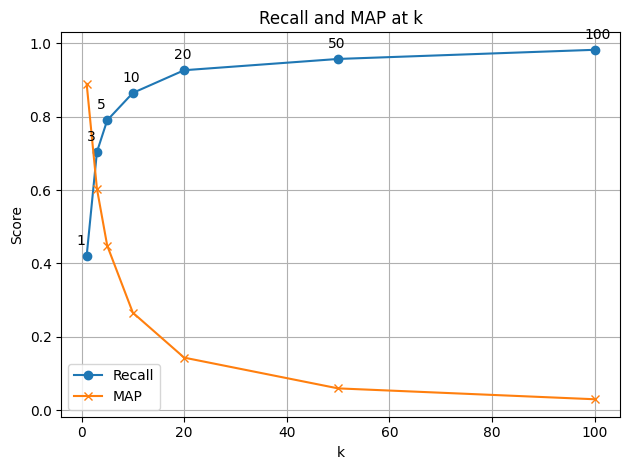

In [ ]:
ls_k = [1, 3, 5, 10, 20, 50, 100]

d_recall = {}
d_map = {}

for k in ls_k:
    recalls = df_preds.apply(lambda x: recall_at_k(x["pred_urls"], x["label"], k), axis=1)
    maps = df_preds.apply(lambda x: map_at_k(x["pred_urls"], x["label"], k), axis=1)
    d_recall[k] = recalls.mean()
    d_map[k] = maps.mean()
    # print(f"Accuracy at {k}: {acc}")
    
import matplotlib.pyplot as plt

plt.plot(list(d_recall.keys()), list(d_recall.values()), label="Recall", marker="o")
plt.plot(list(d_map.keys()), list(d_map.values()), label="MAP", marker="x")
plt.legend()

plt.xlabel("k")
plt.ylabel("Score")
plt.title("Recall and MAP at k")

# Show the k in the plot
for k, v in d_recall.items():
    plt.text(k - 2, v + 0.03, str(k))

plt.grid()
plt.tight_layout()

plt.show()

Here are displayed the results @1, @5 and @10 to continue following the results of the paper.

In [ ]:
k = 20
# print(ls_acc[3])

df_at_k = df_preds[df_val.columns.tolist() + ["pred_urls", "pred_txts", "sims"]].copy()
df_at_k["pred_urls"] = df_at_k["pred_urls"].apply(lambda x: x[:k])
df_at_k["pred_txts"] = df_at_k["pred_txts"].apply(lambda x: x[:k])
df_at_k["sims"] = df_at_k["sims"].apply(lambda x: x[:k])


compute_metrics(df_at_k, [1, 3, 5, 10])

,1,3,5,10
recall,0.421120,0.703704,0.789859,0.864462
map,0.888889,0.603395,0.448704,0.265776
mrr,0.939815,0.939815,0.939815,0.939815


# Transformer cross-encoder re-ranker

In the notebook `2_TRF_Classifier.ipynb` a transformer classifier was trained to classify the relevance of the documents. In this section, we will use this classifier to re-rank the documents retrieved by the retriever. There you can check the performance of the classifier.

In [ ]:
# Deaggregate the predictions to have one row per prediction for the classification task
df_at_k_unroll = df_at_k.explode(["pred_urls", "pred_txts", "sims"])

In [ ]:
from sentence_transformers import CrossEncoder

# Load the CrossEncoder model from file
cross_encoder = CrossEncoder('nbs/other/trf_classifier', device="cuda:1")

arr_out = cross_encoder.predict(df_at_k_unroll[['unverified claim', 'pred_txts']].values.tolist(),
                                show_progress_bar=True,
                                batch_size=32)
arr_out = torch.tensor(arr_out)

Batches:   0%|          | 0/23 [00:00<?, ?it/s]

In [ ]:
# Our cross-encoder model returns the logits for each class. We convert them to probabilities using softmax and take the probability of the positive class
df_at_k_unroll["ce_score"] = torch.softmax(arr_out, dim=1)[:, 1].tolist()

df_at_k_unroll.head()

,claim_id,unverified claim,label,pred_urls,pred_txts,sims,ce_score
0,2,Pilotos de aviación se manifiestan en un aerop...,[https://poligrafo.sapo.pt/fact-check/video-mo...,https://factual.afp.com/doc.afp.com.32DE93V,Video muestra a pilotos protestando contra la ...,0.934433,0.992056
0,2,Pilotos de aviación se manifiestan en un aerop...,[https://poligrafo.sapo.pt/fact-check/video-mo...,https://poligrafo.sapo.pt/fact-check/video-mos...,Centenas de pilotos de avião protestam contra ...,0.928321,0.995980
0,2,Pilotos de aviación se manifiestan en un aerop...,[https://poligrafo.sapo.pt/fact-check/video-mo...,https://www.newtral.es/pilotos-protesta-vacuna...,Los pilotos de la aerolínea Southwest Airlines...,0.917306,0.993181
0,2,Pilotos de aviación se manifiestan en un aerop...,[https://poligrafo.sapo.pt/fact-check/video-mo...,https://factual.afp.com/doc.afp.com.32EA8QV,#ULTIMA HORA I Huelga de más de 400 pilotos de...,0.909085,0.992250
0,2,Pilotos de aviación se manifiestan en un aerop...,[https://poligrafo.sapo.pt/fact-check/video-mo...,https://factuel.afp.com/doc.afp.com.32DY8NY,Des pilotes de Delta Airlines manifestent cont...,0.899385,0.992041


**Note**: The error is because the kernel is restarted but, by matter of time, rerun the notebook wasn't feasible.

In [ ]:
pred_urls = df_at_k_unroll.groupby("claim_id").apply(lambda x: x.sort_values("ce_score", ascending=False)["pred_urls"].tolist(), include_groups=False).reset_index()
pred_txts = df_at_k_unroll.groupby("claim_id").apply(lambda x: x.sort_values("ce_score", ascending=False)["pred_txts"].tolist(), include_groups=False).reset_index()

pred_urls.columns = ["claim_id", "pred_urls"]
pred_txts.columns = ["claim_id", "pred_txts"]
df_ce_preds = pd.merge(df_val, pred_urls, on="claim_id")
df_ce_preds = pd.merge(df_ce_preds, pred_txts, on="claim_id")
df_ce_preds.head()

We can see a significant improvement in the metrics when using the transformer classifier as a re-ranker.

In [ ]:
compute_metrics(df_at_k, [1, 3, 5, 10])

,1,3,5,10
recall,0.421120,0.703704,0.789859,0.864462
map,0.888889,0.603395,0.448704,0.265776
mrr,0.939815,0.939815,0.939815,0.939815


In [ ]:
compute_metrics(df_ce_preds, [1, 3, 5, 10])

,1,3,5,10
recall,0.482231,0.749383,0.831548,0.911795
map,0.972222,0.668210,0.497870,0.300451
mrr,0.986111,0.986111,0.986111,0.986111


# LLM Scorer

In order to use the information of the image, we will use the LLM scorer to re-rank the documents retrieved by the retriever. The LLM scorer takes as input the image and the text and outputs a score. To avoid errors due to wrong requests, the images have been downloaded and a local path to them is provided.

Gemma 3 family model is used as the LLM scorer. The reason for using this model is that it is a large model that can handle multiple languages and it has been trained on a large dataset. Also, it accepts both text and image as input.

The smaller version has been selected because it is faster and it is enough for the task. Better results could be achieved using the larger version but it would be slower. Maybe a good trade-off would be to use a quantized version of the larger model.

The dataset with the images path is `nbs/other/claim_w_verified_images.csv` and it is generated in `download_images.ipynb`.

In [ ]:
df_at_k_unroll = pd.merge(df_at_k_unroll.rename(columns={"pred_urls": "url", "pred_txts": "reviewed claim"}),
                          df_fc, on=["url", "reviewed claim"], how="left")

df_at_k_unroll


,claim_id,unverified claim,label,url,reviewed claim,sims,ce_score,fc_id,title,text,...,cr_country,meta_lang,cr_image,meta_image,movies,domain,cm_authors,cr_author_name,cr_author_url,cr_item_reviewed_text
0,2,Pilotos de aviación se manifiestan en un aerop...,[https://poligrafo.sapo.pt/fact-check/video-mo...,https://factual.afp.com/doc.afp.com.32DE93V,Video muestra a pilotos protestando contra la ...,0.934433,0.992056,5,Estos pilotos protestan por mejores condicione...,Estos pilotos protestan por mejores condicione...,...,Mexico,es,https://factual.afp.com/sites/default/files/st...,https://factual.afp.com/sites/default/files/st...,[],factual.afp.com,[],AFP Factual,factual.afp.com,Video muestra a pilotos protestando contra la ...
1,2,Pilotos de aviación se manifiestan en un aerop...,[https://poligrafo.sapo.pt/fact-check/video-mo...,https://poligrafo.sapo.pt/fact-check/video-mos...,Centenas de pilotos de avião protestam contra ...,0.928321,0.995980,2,Vídeo mostra centenas de pilotos de avião a pr...,"""Última hora! Greve de mais de 400 pilotos do ...",...,Portugal,pt,https://thumbs.web.sapo.io/?W=1200&H=630&delay...,https://thumbs.web.sapo.io/?W=1200&H=630&delay...,[],poligrafo.sapo.pt,"['Polígrafo', 'Gustavo Sampaio']",Polígrafo - SAPO,poligrafo.sapo.pt,Centenas de pilotos de avião protestam contra ...
2,2,Pilotos de aviación se manifiestan en un aerop...,[https://poligrafo.sapo.pt/fact-check/video-mo...,https://www.newtral.es/pilotos-protesta-vacuna...,Los pilotos de la aerolínea Southwest Airlines...,0.917306,0.993181,930,Las imágenes de una concentración de pilotos d...,Las imágenes de una concentración de pilotos d...,...,NaN,es,NaN,https://www.newtral.es/wp-content/uploads/2022...,[],www.newtral.es,"['José Denis Cruz', 'Newtral', 'Por José Denis...",Newtral,https://www.newtral.es/,Los pilotos de la aerolínea Southwest Airlines...
3,2,Pilotos de aviación se manifiestan en un aerop...,[https://poligrafo.sapo.pt/fact-check/video-mo...,https://factual.afp.com/doc.afp.com.32EA8QV,#ULTIMA HORA I Huelga de más de 400 pilotos de...,0.909085,0.992250,6,Estos pilotos no protestan por la vacunación c...,Estos pilotos no protestan por la vacunación c...,...,Mexico,es,https://factual.afp.com/sites/default/files/st...,https://factual.afp.com/sites/default/files/st...,[],factual.afp.com,[],AFP Factual,factual.afp.com,#ULTIMA HORA I Huelga de más de 400 pilotos de...
4,2,Pilotos de aviación se manifiestan en un aerop...,[https://poligrafo.sapo.pt/fact-check/video-mo...,https://factuel.afp.com/doc.afp.com.32DY8NY,Des pilotes de Delta Airlines manifestent cont...,0.899385,0.992041,4,"Non, ces pilotes de Delta Airlines ne manifest...","Non, ces pilotes de Delta Airlines ne manifest...",...,France,fr,https://factuel.afp.com/sites/default/files/st...,https://factuel.afp.com/sites/default/files/st...,[],factuel.afp.com,[],AFP Factuel,factuel.afp.com,Des pilotes de Delta Airlines manifestent cont...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,3616,referéndum de Berlín para expropiar viviendas,[https://factual.afp.com/http%253A%252F%252Fdo...,https://maldita.es/malditobulo/20200317/fumiga...,Van a fumigar Madrid con avionetas\n,0.843719,0.002853,1670,"No, no se va a fumigar Madrid con avionetas a ...","No, no se va a fumigar Madrid con avionetas a ...",...,Spain,es,https://maldita.es/app/uploads/2020/03/PORTADA...,https://maldita.es/app/uploads/2020/03/PORTADA...,[],maldita.es,['Maldita.es'],Maldita.es,https://maldita.es/,Van a fumigar Madrid con avionetas\n
716,3616,referéndum de Berlín para expropiar viviendas,[https://factual.afp.com/http%253A%252F%252Fdo...,https://colombiacheck.com/chequeos/es-falso-qu...,El Acuerdo de Escazú va a prohibir cultivar,0.843684,0.003535,2343,Es falso que el Acuerdo de Escazú vaya a prohi...,"El Senado aprobó el 26 de julio de 2022, en se...",...,Colombia,es,https://colombiacheck.s3.us-east-2.amazonaws.c...,https://colombiacheck.s3.us-east-2.amazonaws.c...,[],colombiac

In [ ]:
# Load the model from Hugging Face
from transformers import pipeline
import torch

pipe = pipeline(
    "image-text-to-text",
    model="google/gemma-3-4b-it",
    device="cuda:1",
    torch_dtype=torch.bfloat16,
    use_fast=True
)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.50, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cuda:1


In [ ]:
# Load the image paths
df_images = pd.read_csv("nbs/other/claim_w_verified_images.csv")
d_img = df_images.set_index("url")["image_path"].to_dict()

df_at_k_unroll["image_path"] = df_at_k_unroll["url"].map(d_img)

In [ ]:
# 2 different instructions for the task are provided
# It provides more transparency using the explanation version but it is also pretty costly in terms of tokens
# Some examples are provided below

def create_message(row):
    unverified_claim = row["unverified claim"]
    reviewed_claim = row["reviewed claim"]
    title = row["title"]
    summary = row["summary"]
    reviewed_text = row["cr_item_reviewed_text"]
    image_path = row["image_path"]
    image_path = image_path if isinstance(image_path, str) else "nbs/other/images/no_image.jpg"
    
    txt =  f"""
    ### Analyze this example:
    
    Unverified Claim: "{unverified_claim}"
    
    Reviewed Claim: "{reviewed_claim}"
    
    Title: "{title}"
    
    Summary: "{summary}"
    
    Reviewed Text: "{reviewed_text}"
    
    An image from the fact checking source is provided.
    """
        
    return txt, image_path


# Instructions as a separate variable
instructions_explanation = """
Your task is to determine how likely a reviewed claim is a fact-check of an unverified claim.

Return your response as a dictionary object with:
- `relatedness_score`: float between 0.0 and 1.0 (1.0 means clearly a fact-check, 0.0 means completely unrelated)
    e.g. 
    - 0.815 for a high likelihood of being a fact-check.
    - 0.223 for a low likelihood of being a fact-check.
    - 0.012 for no relation.    
    
- `justification`: concise reasoning based on text and images (if available).

Follow these reasoning steps:
1. Compare the claims for semantic similarity or direct opposition.
2. Check if the reviewed claim explicitly addresses, confirms, or debunks the unverified claim.
3. Analyze provided textual context (title, summary, article text).
4. Examine images for visual evidence related to claims (e.g., relevant text, scenes, people, manipulated content).
5. Provide a confident relatedness score.
"""

instructions_score = """
Your task is to determine how likely a reviewed claim is a fact-check of an unverified claim.

Return your response as a dictionary object with:
- `relatedness_score`: float between 0.0 and 1.0 (1.0 means clearly a fact-check, 0.0 means completely unrelated)
    e.g. 
    - 0.815 for a high likelihood of being a fact-check.
    - 0.223 for a low likelihood of being a fact-check.
    - 0.012 for no relation. 

Don't provide the explanation, only the score.

Follow these reasoning steps:
1. Compare the claims for semantic similarity or direct opposition.
2. Check if the reviewed claim explicitly addresses, confirms, or debunks the unverified claim.
3. Analyze provided textual context (title, summary, article text).
4. Examine images for visual evidence related to claims (e.g., relevant text, scenes, people, manipulated content).
5. Provide a confident relatedness score.  
"""
from PIL import Image

def predict_row(row, instructions):
    current_claim, img_path = create_message(row)

    messages = [
            {
                "role": "system",
                "content": [
                    {"type": "text", "text": "You are a helpful assistant specialized in matching fact-checked claims to unverified claims."}
                ]
            },
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": instructions},
                    {"type": "text", "text": current_claim},
                    {"type": "image", "url": img_path},
                    {"type": "text", "text": "Please analyze the claims, article content, and image if available. Return your answer in JSON format in a parseable way with python."}
                ]
            }
        ]


    output = pipe(text=messages, max_new_tokens=300, batch_size=1)
    return output[0]["generated_text"][-1]["content"]

print(predict_row(df_at_k_unroll.iloc[0], instructions_explanation))
print(predict_row(df_at_k_unroll.iloc[0], instructions_score))

```json
{
  "relatedness_score": 0.95,
  "justification": "The reviewed claim ('Video muestra a pilotos protestando contra la vacunación covid-19 en Dallas') directly addresses the unverified claim ('Pilotos de aviación se manifiestan en un aeropuerto en contra a la vacunación obligatoria contra el covid-19'). The summary and the reviewed text explicitly state that the protest was *not* about vaccination, but rather about better working conditions. The image, though not available, would likely corroborate this, showing pilots protesting with signs related to their demands, not vaccine opposition."
}
```
```json
{
  "relatedness_score": 0.95
}
```


In [ ]:
df_at_k_unroll_reduced = df_at_k_unroll.groupby("claim_id").apply(lambda x: x.sort_values("ce_score", ascending=False).head(20)).reset_index(drop=True)

/scratch/tmp/17921664/ipykernel_1275011/3624961771.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_at_k_unroll_reduced = df_at_k_unroll.groupby("claim_id").apply(lambda x: x.sort_values("ce_score", ascending=False).head(20)).reset_index(drop=True)


In [ ]:
df_at_k_unroll_reduced["relatedness_score"] = df_at_k_unroll_reduced.progress_apply(lambda x: predict_row(x, instructions_score), axis=1)


In [ ]:
def extract_score(txt):
    try:
        return float(re.search(r"[\d.]+", txt).group())
    except:
        print(txt)
        return None

In [ ]:
df_at_k_unroll_reduced["relatedness_score"] = df_at_k_unroll_reduced["relatedness_score"].apply(extract_score)

In [ ]:
df_at_k_unroll_reduced["relatedness_score"].describe()

count    720.000000
mean       0.892240
std        0.152574
min        0.000000
25%        0.887000
50%        0.950000
75%        0.950000
max        0.995000
Name: relatedness_score, dtype: float64

In [ ]:
pred_urls = df_at_k_unroll_reduced.groupby("claim_id").apply(lambda x: x.sort_values("relatedness_score", ascending=False)["url"].tolist(), include_groups=False).reset_index()
pred_urls.columns = ["claim_id", "pred_urls"]

df_llm_preds = pd.merge(df_val, pred_urls, on="claim_id")
df_llm_preds.head()

,claim_id,unverified claim,label,pred_urls
0,2,Pilotos de aviación se manifiestan en un aerop...,[https://poligrafo.sapo.pt/fact-check/video-mo...,[https://leadstories.com/hoax-alert/2022/07/fa...
1,123,la princesa Leonor aparece en un vídeo con el ...,[https://info-veritas.com/desinformacion-foto-...,[https://www.newtral.es/leonor-tiktok-video-fa...
2,138,"No, la princesa Leonor no tiene un móvil de má...",[https://maldita.es/malditobulo/20200515/princ...,[https://maldita.es/malditobulo/20200515/princ...
3,177,Los menores extranjeros no acompañados no reci...,[https://www.newtral.es/los-menas-no-reciben-m...,[https://www.newtral.es/menas-paga-menores-ext...
4,790,marine le pen obtuvo 14 millones de votos,[https://dpa-factchecking.com/netherlands/2204...,[https://www.newtral.es/es-falso-que-4500-asoc...


We can see that the LLM is not capable of improving the performance of the cross-encoder. Maybe a more in detail prompt and some examples (few shot in context) could improve the performance of the LLM.

In [ ]:
compute_metrics(df_ce_preds, [1, 3, 5, 10])

,1,3,5,10
recall,0.482231,0.749383,0.831548,0.911795
map,0.972222,0.668210,0.497870,0.300451
mrr,0.986111,0.986111,0.986111,0.986111


In [ ]:
compute_metrics(df_llm_preds, [1, 3, 5, 10])

,1,3,5,10
recall,0.293386,0.505732,0.654277,0.835582
map,0.611111,0.404321,0.312870,0.203553
mrr,0.759987,0.759987,0.759987,0.759987


In [ ]:
df_sample = df_at_k_unroll_reduced.sample(5)

SOme examples of the explanations are provided

In [ ]:
df_sample["response"] = df_sample.progress_apply(lambda x: predict_row(x, instructions=instructions_explanation), axis=1)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:20<00:00,  4.11s/it]


In [ ]:
df_sample["response"].values

array(['```json\n{\n  "relatedness_score": 0.95,\n  "justification": "The reviewed claim directly opposes the unverified claim. The fact-check article explicitly states that being Spanish does not exclude eligibility for unemployment benefits. The image shows a denial of a \'prestación por desempleo\' (unemployment benefit) specifically for Spanish nationals, confirming the reviewed claim. The article context emphasizes that nationality is not a requirement for these benefits and identifies a manipulated image representing a false claim."\n}\n```',
       '```json\n{\n  "relatedness_score": 0.88,\n  "justification": "The reviewed claim directly addresses and refutes the unverified claim. The article states that official data does not record the nationalities of sexual offenders, and the image presented (along with the article\'s text) shows specific nationalities of perpetrators (Romanians, Ecuadorian, etc.) - thus demonstrating that the initial claim is based on false data. The image 

# Machine Learning Classifier

The Random Forest classifier trained in the `1_ML_Classifier.ipynb` notebook is used to re-rank the documents retrieved by the retriever. The classifier uses different features to score the documents.

In [ ]:
import joblib
model_rf = joblib.load("nbs/other/ml_classifier/rf.pkl")

In [ ]:
# Feature Extraction for Claim Matching

import pandas as pd
import numpy as np
import torch
from tqdm import tqdm
from sentence_transformers import SentenceTransformer, util
import spacy
from sklearn.metrics.pairwise import cosine_similarity
from datetime import datetime
from dateutil.parser import parse as parse_date
from rapidfuzz import fuzz

from transformers import AutoTokenizer
from sentence_transformers import CrossEncoder
from langdetect import detect
from keybert import KeyBERT


EMB_MODEL_NAME = "intfloat/multilingual-e5-large"
CE_MODEL_NAME = "cross-encoder/nli-deberta-v3-large"

# Load NLP model for linguistic features
nlp = spacy.load("xx_ent_wiki_sm")  # multilingual model

# Load sentence embedding model
embedding_model = SentenceTransformer(EMB_MODEL_NAME)

# # Force slow tokenizer
# tokenizer = AutoTokenizer.from_pretrained(CE_MODEL_NAME,)

# Then load the model using CrossEncoder, passing the tokenizer manually
nli_model = CrossEncoder(
    model_name=CE_MODEL_NAME,
    # tokenizer_args={"tokenizer": tokenizer}
)

kw_model = KeyBERT(EMB_MODEL_NAME)

from tqdm import tqdm
tqdm.pandas()

# df["unverified claim_keywords"] = df["unverified claim"].progress_apply(lambda x: kw_model.extract_keywords(x, keyphrase_ngram_range=(1, 3), stop_words=None))
def create_features(df):
    # --- Feature functions ---
    def compute_cosine_sim(text1, text2):
        if pd.isna(text1) or pd.isna(text2):
            return 0.0
        emb1 = embedding_model.encode(text1, convert_to_tensor=True)
        emb2 = embedding_model.encode(text2, convert_to_tensor=True)
        return util.cos_sim(emb1, emb2).item()

    def nli_contradiction(claim, evidence):
        return torch.tensor(nli_model.predict([(claim, evidence)])[0]).softmax(dim=0)[0].item()

    def token_overlap(text1, text2):
        tokens1 = set(str(text1).lower().split())
        tokens2 = set(str(text2).lower().split())
        return len(tokens1 & tokens2) / (len(tokens1 | tokens2) + 1e-5)

    def lang_match(text, lang):
        try:
            return int(detect(str(text)) == lang)
        except:
            return 0

    def has_negation(text):
        return int(any(tok.lower_ in ["no", "not", "nunca", "ni", "sin", "n'est", "non"] for tok in nlp(str(text))))

    def shared_named_entities(text1, text2):
        ents1 = set([ent.text.lower() for ent in nlp(str(text1)).ents])
        ents2 = set([ent.text.lower() for ent in nlp(str(text2)).ents])
        return len(ents1 & ents2)
        
    def keyword_overlap(kb_keywords, claim):
            
        try:
            if isinstance(kb_keywords, str):
                keywords = eval(kb_keywords)  # list of (kw, score)
            else:
                keywords = kb_keywords
            
            # print(keywords)
            kw_claim = kw_model.extract_keywords(claim, keyphrase_ngram_range=(1, 3), stop_words=None)
            kw_claim = [kw for kw, _ in kw_claim]
            # print(kw_claim)

            return len([k for k, _ in keywords if k in kw_claim])
        except:
            return 0


    def text_length(text):
        return len(str(text).split())

    def fuzzy_title_match(title, claim):
        return fuzz.partial_ratio(str(title), str(claim)) / 100

    feature_df = pd.DataFrame()

    # print("Extracting keywords...")
    # feature_df["unverified claim_keywords"] = df["unverified claim"].progress_apply(lambda x: kw_model.extract_keywords(x, keyphrase_ngram_range=(1, 3), stop_words=None))
    
    # --- Apply feature engineering ---

    feature_df['ft_cosine_claim_reviewed'] = df.progress_apply(lambda x: compute_cosine_sim(x["unverified claim"], x["reviewed claim"]), axis=1)
    feature_df['ft_cosine_claim_summary'] = df.progress_apply(lambda x: compute_cosine_sim(x["unverified claim"], x["summary"]), axis=1)
    feature_df['ft_cosine_claim_meta_desc'] = df.progress_apply(lambda x: compute_cosine_sim(x["unverified claim"], x["meta_description"]), axis=1)

    # Token overlap and shared named entities
    feature_df['ft_token_overlap'] = df.progress_apply(lambda x: token_overlap(x["unverified claim"], x["reviewed claim"]), axis=1)
    feature_df['ft_shared_named_entities'] = df.progress_apply(lambda x: shared_named_entities(x["unverified claim"], x["reviewed claim"]), axis=1)

    # Boolean flags (easy vectorizations)
    feature_df['ft_has_negation'] = df['unverified claim'].apply(has_negation).astype(int)
    feature_df['ft_has_negation_reviewed'] = df['reviewed claim'].apply(has_negation).astype(int)

    # Keyword overlaps
    print("Computing keyword overlaps...")

    feature_df['ft_keyword_overlap_kb'] = df.progress_apply(lambda x: keyword_overlap(x["kb_keywords"], x["unverified claim"]), axis=1)
    feature_df['ft_keyword_overlap_meta'] = df.progress_apply(lambda x: keyword_overlap(x["meta_keywords"], x["unverified claim"]), axis=1)

    # Domain match (fully vectorized)
    feature_df['ft_domain_match'] = ((df['url'].notna()) & (df.apply(lambda row: row['domain'] in row['url'], axis=1))).astype(int)

    # Language match and image/video presence
    feature_df['ft_lang_match'] = df.progress_apply(lambda x: lang_match(x["unverified claim"], x["meta_lang"]), axis=1)
    feature_df['ft_has_image'] = df['cr_image'].notna().astype(int)
    feature_df['ft_has_video'] = df['movies'].apply(lambda x: int(len(eval(x)) > 0) if pd.notna(x) else 0)

    # Text lengths
    feature_df['ft_text_len_summary'] = df['summary'].apply(text_length)
    feature_df['ft_text_len_meta'] = df['meta_description'].apply(text_length)

    # Fuzzy matching
    feature_df['ft_title_match_ratio'] = df.progress_apply(lambda x: fuzzy_title_match(x["title"], x["unverified claim"]), axis=1)


    nli_probs = nli_model.predict(df[["unverified claim", "reviewed claim"]].fillna("").values.tolist())
    nli_probs = torch.tensor(nli_probs).softmax(dim=1).numpy()
    feature_df["ft_contr_nli_claim_reviewed"] = nli_probs[:, 0]

    nli_probs = nli_model.predict(df[["unverified claim", "summary"]].fillna("").values.tolist())
    nli_probs = torch.tensor(nli_probs).softmax(dim=1).numpy()
    feature_df["ft_contr_nli_claim_summary"] = nli_probs[:, 0]

    nli_probs = nli_model.predict(df[["unverified claim", "meta_description"]].fillna("").values.tolist())
    nli_probs = torch.tensor(nli_probs).softmax(dim=1).numpy()
    feature_df["ft_contr_nli_claim_meta_desc"] = nli_probs[:, 0]

    return feature_df

No sentence-transformers model found with name intfloat/multilingual-e5-large. Creating a new one with mean pooling.
/gpfs/projects/bsc14/scratch/.conda/factcheck/lib/python3.10/site-packages/transformers/convert_slow_tokenizer.py:559: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
No sentence-transformers model found with name intfloat/multilingual-e5-large. Creating a new one with mean pooling.


In [ ]:
df_features = create_features(df_at_k_unroll_reduced)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 720/720 [00:02<00:00, 347.89it/s]


Computing keyword overlaps...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 720/720 [00:00<00:00, 81504.34it/s]


In [ ]:
ml_scores = model_rf.predict_proba(df_features)[:, 1]
ml_scores

array([9.32939394e-01, 8.96672619e-01, 8.71273810e-01, 7.70966014e-01,
       8.89523810e-01, 9.15518931e-01, 6.72992857e-01, 6.21395833e-01,
       7.86690972e-02, 4.37171326e-01, 3.82845794e-01, 2.20770474e-02,
       1.57007353e-01, 4.33764949e-02, 4.03221305e-02, 1.46869568e-01,
       1.16278631e-01, 3.72261809e-03, 5.79063820e-02, 2.28635307e-02,
       9.07733871e-01, 7.33339827e-01, 6.49327922e-01, 3.70184524e-01,
       1.73058874e-01, 7.13620776e-01, 2.04411112e-02, 5.75891768e-02,
       1.03891907e-02, 4.39901188e-03, 1.05664503e-01, 2.11708993e-01,
       1.01610762e-03, 1.15991849e-02, 7.07867784e-03, 9.02778834e-03,
       8.26950864e-03, 4.98718348e-02, 4.69925721e-03, 2.24715374e-03,
       7.34821429e-01, 7.82035714e-01, 6.57845238e-01, 1.01674336e-01,
       3.84299242e-01, 1.68205065e-01, 1.86067174e-01, 8.74691788e-02,
       1.68981092e-01, 8.77483110e-02, 2.54082388e-02, 2.74857035e-02,
       1.03568031e-01, 5.39477179e-02, 8.80046187e-02, 3.54165440e-02,
      

In [ ]:
df_at_k_unroll_reduced["ml_score"] = ml_scores

In [ ]:
pred_urls = df_at_k_unroll_reduced.groupby("claim_id").apply(lambda x: x.sort_values("ml_score", ascending=False)["url"].tolist(), include_groups=False).reset_index()

pred_urls.columns = ["claim_id", "pred_urls"]

df_ml_preds = pd.merge(df_val, pred_urls, on="claim_id")
df_ml_preds.head()

,claim_id,unverified claim,label,pred_urls
0,2,Pilotos de aviación se manifiestan en un aerop...,[https://poligrafo.sapo.pt/fact-check/video-mo...,[https://poligrafo.sapo.pt/fact-check/video-mo...
1,123,la princesa Leonor aparece en un vídeo con el ...,[https://info-veritas.com/desinformacion-foto-...,[https://info-veritas.com/desinformacion-foto-...
2,138,"No, la princesa Leonor no tiene un móvil de má...",[https://maldita.es/malditobulo/20200515/princ...,[https://maldita.es/malditobulo/20200515/princ...
3,177,Los menores extranjeros no acompañados no reci...,[https://www.newtral.es/los-menas-no-reciben-m...,[https://factual.afp.com/http%253A%252F%252Fdo...
4,790,marine le pen obtuvo 14 millones de votos,[https://dpa-factchecking.com/netherlands/2204...,[https://dpa-factchecking.com/netherlands/2204...


Very decent results are obtained only by using the Random Forest classifier. This is because the classifier has been trained with different features that are not used by the other re-rankers.

The feature importance can be seen in the notebook `1_ML_Classifier.ipynb`.

In [ ]:
compute_metrics(df_ml_preds, [1, 3, 5, 10])

,1,3,5,10
recall,0.430644,0.745679,0.829784,0.911795
map,0.944444,0.660494,0.494907,0.300995
mrr,0.972222,0.972222,0.972222,0.972222


## Ensemble

It is well known that ensembles can improve the performance of the models. In this section, we will use a hard voting ensemble of the previous models to re-rank the documents retrieved by the retriever.

We have observed some contradictory results between the cross-encoder and the bi-encoder. The main reason can be that the first one hasn't been trained with the data and, hence, doesn't consider opposite examples as similar (definition of similarity associated to fact-checking).

It consists in adding the scores of the previous models and sorting. The ensemble improves the performance of the models. This is because the ensemble combines the strengths of the models and mitigates their weaknesses.


In [ ]:
df_ensemble = df_at_k_unroll_reduced.copy()
df_ensemble["voting_score"] = df_ensemble["relatedness_score"] + df_ensemble["ce_score"]  + df_ensemble["ml_score"] + df_ensemble["sims"]

pred_urls = df_ensemble.groupby("claim_id").apply(lambda x: x.sort_values("voting_score", ascending=False)["url"].tolist(), include_groups=False).reset_index()
# pred_txts = df_at_k_unroll_reduced.groupby("claim_id").apply(lambda x: x.sort_values("relatedness_score", ascending=False)["txts"].tolist(), include_groups=False).reset_index()

pred_urls.columns = ["claim_id", "pred_urls"]
# pred_txts.columns = ["claim_id", "pred_txts"]
df_ensemble_preds = pd.merge(df_val, pred_urls, on="claim_id")
# df_llm_preds = pd.merge(df_llm_preds, pred_txts, on="claim_id")

compute_metrics(df_ensemble_preds, [1, 3, 5, 10])

NameError: name 'df_at_k_unroll_reduced' is not defined

# Final Comparison

In [ ]:
df_scores = compute_metrics(df_at_k, [1, 3, 5, 10]).T
df_scores["model"] = "Biencoder"

df_scores_ce = compute_metrics(df_ce_preds, [1, 3, 5, 10]).T
df_scores_ce["model"] = "CrossEncoder"

df_scores_llm = compute_metrics(df_llm_preds, [1, 3, 5, 10]).T
df_scores_llm["model"] = "LLM"

df_scores_ml = compute_metrics(df_ml_preds, [1, 3, 5, 10]).T
df_scores_ml["model"] = "ML"

df_scores_ensemble = compute_metrics(df_ensemble_preds, [1, 3, 5, 10]).T
df_scores_ensemble["model"] = "Ensemble"

df_scores_all = pd.concat([df_scores_ensemble, df_scores, df_scores_ce, df_scores_llm, df_scores_ml])

df_scores_all

,recall,map,mrr,model
1,0.486199,1.000000,1.000000,Ensemble
3,0.761684,0.700617,1.000000,Ensemble
5,0.830622,0.507870,1.000000,Ensemble
10,0.914572,0.310000,1.000000,Ensemble
1,0.421120,0.888889,0.939815,Biencoder
3,0.703704,0.603395,0.939815,Biencoder
5,0.789859,0.448704,0.939815,Biencoder
10,0.864462,0.265776,0.939815,Biencoder
1,0.482231,0.972222,0.986111,CrossEncoder
3,0.749383,0.668210,0.986111,CrossEncoder


In [ ]:
for metric in ["recall", "map"]:
    print("Top 2 models for", metric)
    print(df_scores_all.sort_values(metric, ascending=False).head(2))
    print()

Top 2 models for recall
      recall       map       mrr         model
10  0.914572  0.310000  1.000000      Ensemble
10  0.911795  0.300451  0.986111  CrossEncoder

Top 2 models for map
     recall       map       mrr         model
1  0.486199  1.000000  1.000000      Ensemble
1  0.482231  0.972222  0.986111  CrossEncoder



# Inference on test set

The inference in test set would be recommended but due to the amount of resources needed to run the notebook, it is not going to be done. It is basically repeating the same steps but with the test set.